In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Customer_Revenue_Intelligence\data\processed\online_retail_clean.csv",
                 parse_dates=['InvoiceDate'])

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

print(f"Clean dataset loaded: {len(df):,} rows, {df.shape[1]} columns")
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"Total Revenue: £{df['Revenue'].sum():,.2f}")

Clean dataset loaded: 779,407 rows, 12 columns
Date range: 2009-12-01 to 2011-12-09
Total Revenue: £17,374,804.25


In [2]:
monthly_revenue = df.groupby('YearMonth').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('Invoice', 'nunique'),
    Customers=('Customer ID', 'nunique')
).reset_index()

monthly_revenue['YearMonth_str'] = monthly_revenue['YearMonth'].astype(str)
monthly_revenue['AOV'] = (monthly_revenue['Revenue'] / monthly_revenue['Orders']).round(2)

print("=== MONTHLY REVENUE SUMMARY ===")
print(monthly_revenue[['YearMonth_str', 'Revenue', 'Orders', 'Customers', 'AOV']].to_string())
print(f"\nBest revenue month:  {monthly_revenue.loc[monthly_revenue['Revenue'].idxmax(), 'YearMonth_str']} — £{monthly_revenue['Revenue'].max():,.2f}")
print(f"Worst revenue month: {monthly_revenue.loc[monthly_revenue['Revenue'].idxmin(), 'YearMonth_str']} — £{monthly_revenue['Revenue'].min():,.2f}")
print(f"Average monthly revenue: £{monthly_revenue['Revenue'].mean():,.2f}")
print(f"Average order value overall: £{monthly_revenue['AOV'].mean():,.2f}")

=== MONTHLY REVENUE SUMMARY ===
   YearMonth_str     Revenue  Orders  Customers     AOV
0        2009-12   683504.01    1512        955  452.05
1        2010-01   555802.67    1011        720  549.76
2        2010-02   504558.95    1104        772  457.03
3        2010-03   696978.47    1524       1057  457.33
4        2010-04   591982.00    1329        942  445.43
5        2010-05   597833.38    1377        966  434.16
6        2010-06   636371.13    1497       1041  425.10
7        2010-07   589736.17    1381        928  427.04
8        2010-08   602224.60    1293        911  465.76
9        2010-09   829013.95    1689       1145  490.83
10       2010-10  1033112.01    2133       1497  484.35
11       2010-11  1166460.02    2587       1607  450.89
12       2010-12   570422.73    1400        885  407.44
13       2011-01   568101.31     987        741  575.58
14       2011-02   446084.92     997        758  447.43
15       2011-03   594081.76    1321        974  449.72
16       2011-04

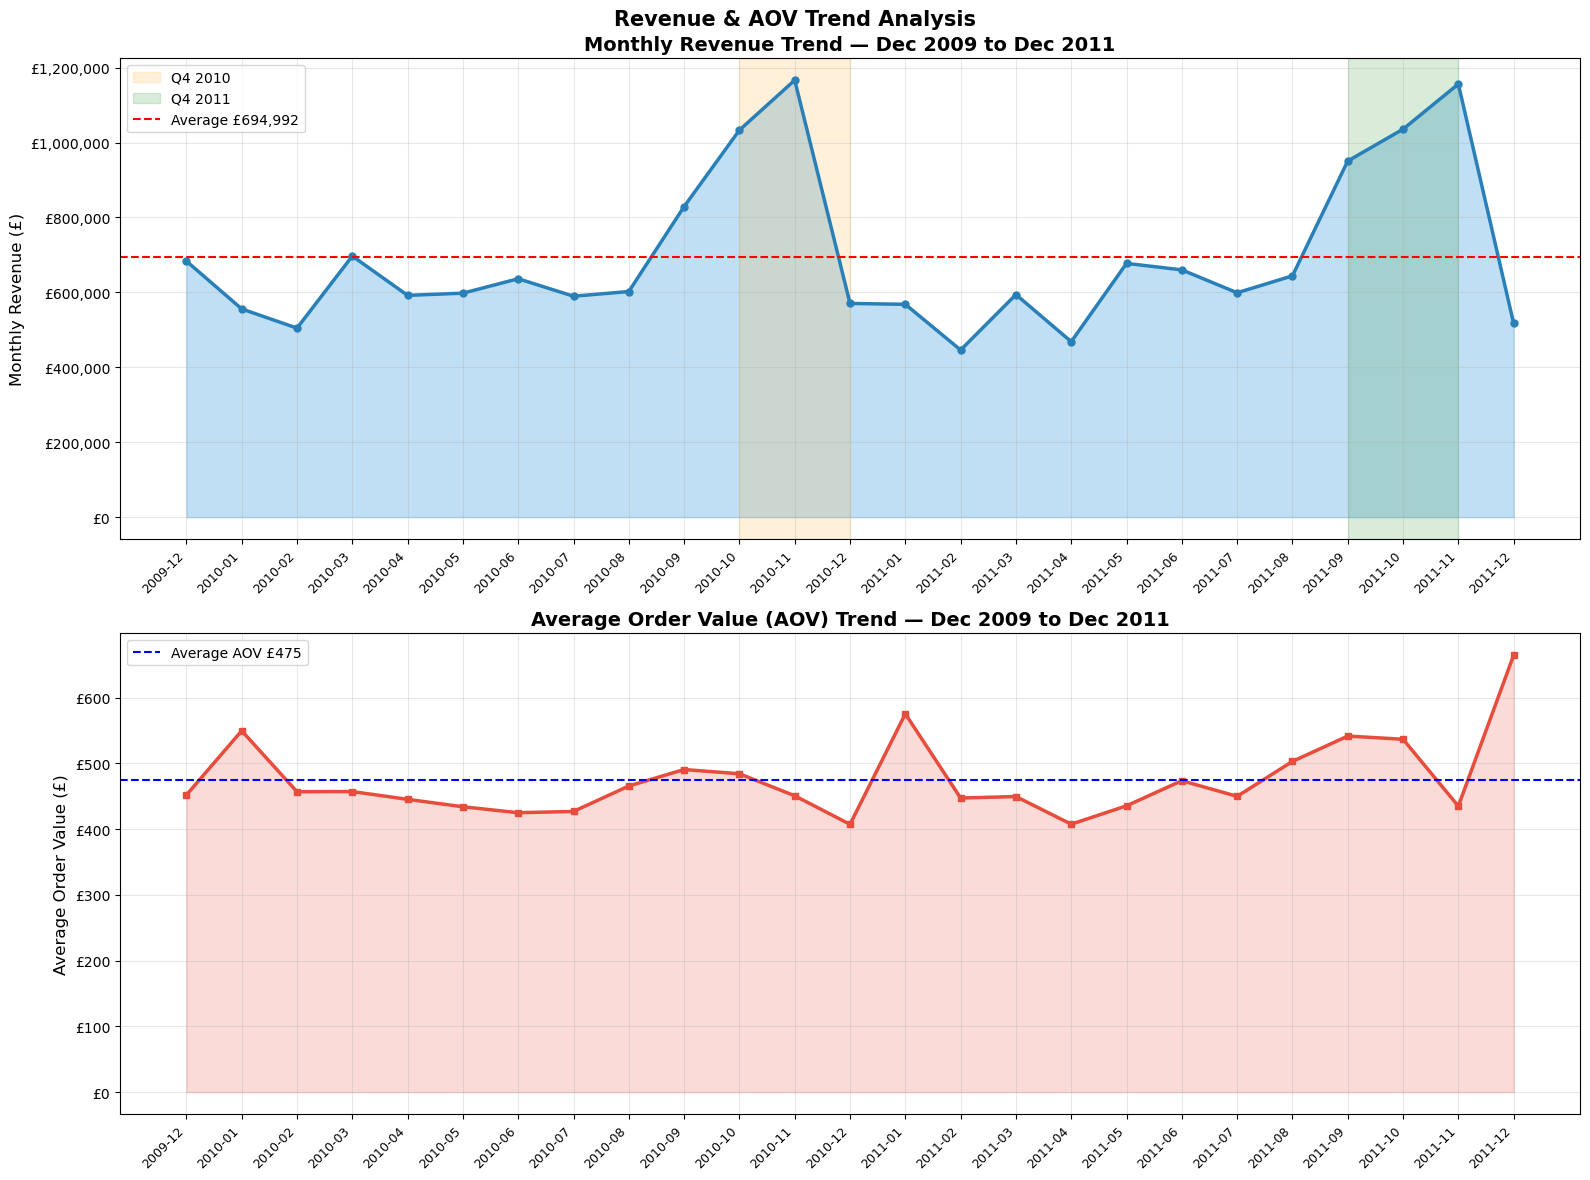

Monthly revenue trend chart saved to reports/figures/


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

axes[0].fill_between(range(len(monthly_revenue)), monthly_revenue['Revenue'],
                     alpha=0.3, color='#3498db')
axes[0].plot(range(len(monthly_revenue)), monthly_revenue['Revenue'],
             color='#2980b9', linewidth=2.5, marker='o', markersize=5)
axes[0].set_xticks(range(len(monthly_revenue)))
axes[0].set_xticklabels(monthly_revenue['YearMonth_str'], rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Monthly Revenue (£)', fontsize=12)
axes[0].set_title('Monthly Revenue Trend — Dec 2009 to Dec 2011', fontsize=14, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
axes[0].axvspan(10, 12, alpha=0.15, color='orange', label='Q4 2010')
axes[0].axvspan(21, 23, alpha=0.15, color='green', label='Q4 2011')
axes[0].axhline(y=monthly_revenue['Revenue'].mean(), color='red',
                linestyle='--', linewidth=1.5, label=f'Average £{monthly_revenue["Revenue"].mean():,.0f}')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(len(monthly_revenue)), monthly_revenue['AOV'],
             color='#e74c3c', linewidth=2.5, marker='s', markersize=5)
axes[1].fill_between(range(len(monthly_revenue)), monthly_revenue['AOV'],
                     alpha=0.2, color='#e74c3c')
axes[1].set_xticks(range(len(monthly_revenue)))
axes[1].set_xticklabels(monthly_revenue['YearMonth_str'], rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Average Order Value (£)', fontsize=12)
axes[1].set_title('Average Order Value (AOV) Trend — Dec 2009 to Dec 2011', fontsize=14, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
axes[1].axhline(y=monthly_revenue['AOV'].mean(), color='blue',
                linestyle='--', linewidth=1.5, label=f'Average AOV £{monthly_revenue["AOV"].mean():,.0f}')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Revenue & AOV Trend Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Customer_Revenue_Intelligence\reports\figures\monthly_revenue_trend.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Monthly revenue trend chart saved to reports/figures/")

In [4]:
country_revenue = df.groupby('Country').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('Invoice', 'nunique'),
    Customers=('Customer ID', 'nunique')
).round(2)

country_revenue['Revenue %'] = (country_revenue['Revenue'] / country_revenue['Revenue'].sum() * 100).round(2)
country_revenue = country_revenue.sort_values('Revenue', ascending=False)

print("=== REVENUE BY COUNTRY (Top 15) ===")
print(country_revenue.head(15).to_string())
print(f"\nUK Revenue: £{country_revenue.loc['United Kingdom', 'Revenue']:,.2f}")
print(f"UK Revenue %: {country_revenue.loc['United Kingdom', 'Revenue %']}%")
print(f"Non-UK Revenue: £{country_revenue[country_revenue.index != 'United Kingdom']['Revenue'].sum():,.2f}")
print(f"Non-UK Revenue %: {country_revenue[country_revenue.index != 'United Kingdom']['Revenue %'].sum():.2f}%")

=== REVENUE BY COUNTRY (Top 15) ===
                     Revenue  Orders  Customers  Revenue %
Country                                                   
United Kingdom   14389234.90   33541       5350      82.82
EIRE               616570.54     567          5       3.55
Netherlands        554038.09     228         22       3.19
Germany            425019.71     789        107       2.45
France             348768.96     614         95       2.01
Australia          169283.46      95         15       0.97
Spain              108332.49     154         41       0.62
Switzerland        100061.94      90         22       0.58
Sweden              91515.82     104         19       0.53
Denmark             68580.69      43         12       0.39
Belgium             65387.82     149         29       0.38
Norway              56322.50      45         13       0.32
Portugal            55554.78      93         24       0.32
Channel Islands     44623.33      55         13       0.26
Japan               

In [5]:
customer_revenue = df.groupby('Customer ID')['Revenue'].sum().reset_index()
customer_revenue = customer_revenue.sort_values('Revenue', ascending=False).reset_index(drop=True)

customer_revenue['Cumulative Revenue'] = customer_revenue['Revenue'].cumsum()
customer_revenue['Cumulative Revenue %'] = (customer_revenue['Cumulative Revenue'] / customer_revenue['Revenue'].sum() * 100).round(4)
customer_revenue['Customer Rank %'] = ((customer_revenue.index + 1) / len(customer_revenue) * 100).round(4)

total_customers = len(customer_revenue)
total_revenue = customer_revenue['Revenue'].sum()

cutoff_80 = customer_revenue[customer_revenue['Cumulative Revenue %'] >= 80].iloc[0]
cutoff_index = customer_revenue[customer_revenue['Cumulative Revenue %'] >= 80].index[0]

print("=== PARETO ANALYSIS — CUSTOMERS ===")
print(f"Total customers: {total_customers:,}")
print(f"Total revenue: £{total_revenue:,.2f}")
print(f"\n80% of revenue generated by:")
print(f"  {cutoff_index + 1:,} customers out of {total_customers:,}")
print(f"  That is {round((cutoff_index + 1)/total_customers*100, 2)}% of all customers")
print(f"\nTop 10% of customers ({int(total_customers*0.1):,} customers) generate:")
top10_rev = customer_revenue.head(int(total_customers*0.1))['Revenue'].sum()
print(f"  £{top10_rev:,.2f} — {round(top10_rev/total_revenue*100, 2)}% of total revenue")
print(f"\nTop 20% of customers ({int(total_customers*0.2):,} customers) generate:")
top20_rev = customer_revenue.head(int(total_customers*0.2))['Revenue'].sum()
print(f"  £{top20_rev:,.2f} — {round(top20_rev/total_revenue*100, 2)}% of total revenue")
print(f"\nBottom 50% of customers ({int(total_customers*0.5):,} customers) generate:")
bot50_rev = customer_revenue.tail(int(total_customers*0.5))['Revenue'].sum()
print(f"  £{bot50_rev:,.2f} — {round(bot50_rev/total_revenue*100, 2)}% of total revenue")

=== PARETO ANALYSIS — CUSTOMERS ===
Total customers: 5,878
Total revenue: £17,374,804.25

80% of revenue generated by:
  1,354 customers out of 5,878
  That is 23.04% of all customers

Top 10% of customers (587 customers) generate:
  £11,101,666.95 — 63.9% of total revenue

Top 20% of customers (1,175 customers) generate:
  £13,418,862.78 — 77.23% of total revenue

Bottom 50% of customers (2,939 customers) generate:
  £1,116,542.29 — 6.43% of total revenue


In [6]:
product_revenue = df.groupby('StockCode').agg(
    Revenue=('Revenue', 'sum'),
    Quantity=('Quantity', 'sum'),
    Description=('Description', 'first')
).reset_index()

product_revenue = product_revenue.sort_values('Revenue', ascending=False).reset_index(drop=True)
product_revenue['Cumulative Revenue'] = product_revenue['Revenue'].cumsum()
product_revenue['Cumulative Revenue %'] = (product_revenue['Cumulative Revenue'] / product_revenue['Revenue'].sum() * 100).round(4)
product_revenue['Product Rank %'] = ((product_revenue.index + 1) / len(product_revenue) * 100).round(4)

total_products = len(product_revenue)
cutoff_80_prod = product_revenue[product_revenue['Cumulative Revenue %'] >= 80].index[0]

print("=== PARETO ANALYSIS — PRODUCTS ===")
print(f"Total unique products: {total_products:,}")
print(f"\n80% of revenue generated by:")
print(f"  {cutoff_80_prod + 1:,} products out of {total_products:,}")
print(f"  That is {round((cutoff_80_prod + 1)/total_products*100, 2)}% of all products")
print(f"\nTop 10 products by revenue:")
print(product_revenue[['StockCode','Description','Revenue','Quantity']].head(10).to_string())
print(f"\nTop 10% of products ({int(total_products*0.1):,} products) generate:")
top10_prod_rev = product_revenue.head(int(total_products*0.1))['Revenue'].sum()
print(f"  £{top10_prod_rev:,.2f} — {round(top10_prod_rev/product_revenue['Revenue'].sum()*100, 2)}% of total revenue")

=== PARETO ANALYSIS — PRODUCTS ===
Total unique products: 4,630

80% of revenue generated by:
  992 products out of 4,630
  That is 21.43% of all products

Top 10 products by revenue:
  StockCode                         Description    Revenue  Quantity
0     22423            REGENCY CAKESTAND 3 TIER  277656.25     24124
1    85123A  WHITE HANGING HEART T-LIGHT HOLDER  247203.36     91814
2     23843         PAPER CRAFT , LITTLE BIRDIE  168469.60     80995
3    85099B         JUMBO BAG RED WHITE SPOTTY   167920.64     93436
4         M                              Manual  151777.67      9384
5      POST                             POSTAGE  124648.04      5235
6     84879       ASSORTED COLOUR BIRD ORNAMENT  124351.86     78234
7     47566                       PARTY BUNTING  103283.38     23460
8     23166      MEDIUM CERAMIC TOP STORAGE JAR   81416.73     77916
9     22086     PAPER CHAIN KIT 50'S CHRISTMAS    76598.18     28380

Top 10% of products (463 products) generate:
  £10,852,4

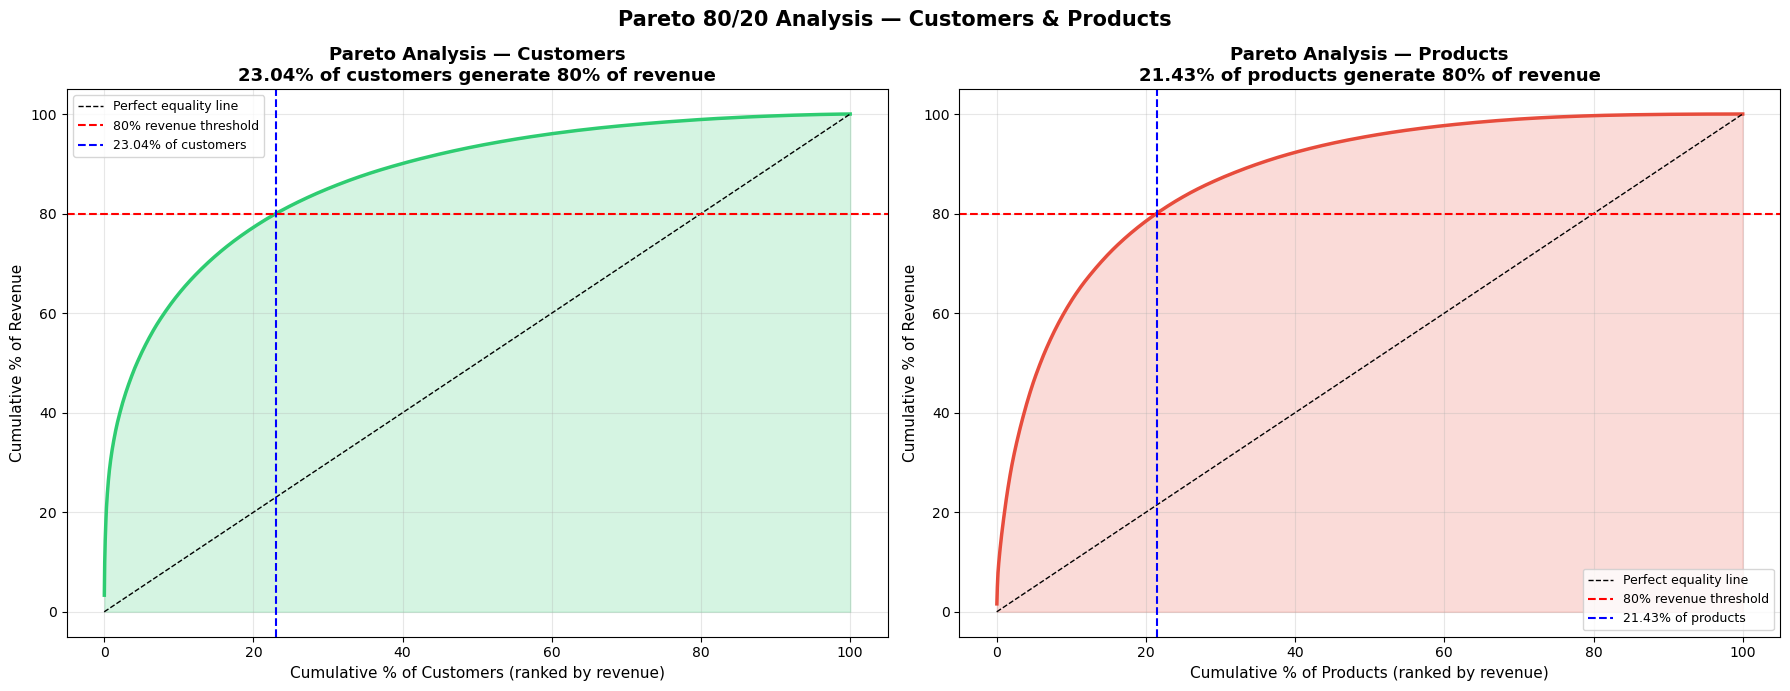

Pareto chart saved to reports/figures/


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].plot(customer_revenue['Customer Rank %'],
             customer_revenue['Cumulative Revenue %'],
             color='#2ecc71', linewidth=2.5)
axes[0].plot([0, 100], [0, 100], 'k--', linewidth=1, label='Perfect equality line')
axes[0].axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='80% revenue threshold')
axes[0].axvline(x=23.04, color='blue', linestyle='--', linewidth=1.5, label='23.04% of customers')
axes[0].fill_between(customer_revenue['Customer Rank %'],
                     customer_revenue['Cumulative Revenue %'], alpha=0.2, color='#2ecc71')
axes[0].set_xlabel('Cumulative % of Customers (ranked by revenue)', fontsize=11)
axes[0].set_ylabel('Cumulative % of Revenue', fontsize=11)
axes[0].set_title('Pareto Analysis — Customers\n23.04% of customers generate 80% of revenue',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(product_revenue['Product Rank %'],
             product_revenue['Cumulative Revenue %'],
             color='#e74c3c', linewidth=2.5)
axes[1].plot([0, 100], [0, 100], 'k--', linewidth=1, label='Perfect equality line')
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='80% revenue threshold')
axes[1].axvline(x=21.43, color='blue', linestyle='--', linewidth=1.5, label='21.43% of products')
axes[1].fill_between(product_revenue['Product Rank %'],
                     product_revenue['Cumulative Revenue %'], alpha=0.2, color='#e74c3c')
axes[1].set_xlabel('Cumulative % of Products (ranked by revenue)', fontsize=11)
axes[1].set_ylabel('Cumulative % of Revenue', fontsize=11)
axes[1].set_title('Pareto Analysis — Products\n21.43% of products generate 80% of revenue',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Pareto 80/20 Analysis — Customers & Products', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Customer_Revenue_Intelligence\reports\figures\pareto_analysis.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Pareto chart saved to reports/figures/")

In [8]:
print("=" * 60)
print("REVENUE TREND ANALYSIS SUMMARY")
print("=" * 60)
print(f"\nTOTAL REVENUE: £{df['Revenue'].sum():,.2f}")
print(f"Date range: Dec 2009 — Dec 2011 (25 months)")
print(f"Total orders: {df['Invoice'].nunique():,}")
print(f"Total customers: {df['Customer ID'].nunique():,}")
print(f"Average order value: £{df['Revenue'].sum()/df['Invoice'].nunique():,.2f}")

print(f"\n--- SEASONAL FINDINGS ---")
print(f"Best revenue month:  Nov 2010 — £1,166,460")
print(f"Second best month:   Nov 2011 — £1,156,205")
print(f"Worst revenue month: Feb 2011 — £446,084")
print(f"Q4 consistently drives highest revenue both years")

print(f"\n--- GEOGRAPHIC FINDINGS ---")
print(f"UK revenue:     £14,389,234 — 82.82% of total")
print(f"Non-UK revenue: £2,985,569  — 17.18% of total")
print(f"Top 5 countries drive 93.02% of all revenue")

print(f"\n--- PARETO FINDINGS — CUSTOMERS ---")
print(f"23.04% of customers (1,354) generate 80% of revenue")
print(f"Top 10% (587 customers) generate 63.90% of revenue")
print(f"Bottom 50% (2,939 customers) generate only 6.43% of revenue")

print(f"\n--- PARETO FINDINGS — PRODUCTS ---")
print(f"21.43% of products (992) generate 80% of revenue")
print(f"Top 10% (463 products) generate 62.46% of revenue")
print(f"Top product: REGENCY CAKESTAND 3 TIER — £277,656")

print(f"\n--- DATA QUALITY FLAGS ---")
print(f"StockCode 'M' (Manual) — £151,777 — not a real product")
print(f"StockCode 'POST' (Postage) — £124,648 — not product revenue")
print(f"Both flagged honestly — not removed to preserve order totals")
print("=" * 60)

REVENUE TREND ANALYSIS SUMMARY

TOTAL REVENUE: £17,374,804.25
Date range: Dec 2009 — Dec 2011 (25 months)
Total orders: 36,969
Total customers: 5,878
Average order value: £469.98

--- SEASONAL FINDINGS ---
Best revenue month:  Nov 2010 — £1,166,460
Second best month:   Nov 2011 — £1,156,205
Worst revenue month: Feb 2011 — £446,084
Q4 consistently drives highest revenue both years

--- GEOGRAPHIC FINDINGS ---
UK revenue:     £14,389,234 — 82.82% of total
Non-UK revenue: £2,985,569  — 17.18% of total
Top 5 countries drive 93.02% of all revenue

--- PARETO FINDINGS — CUSTOMERS ---
23.04% of customers (1,354) generate 80% of revenue
Top 10% (587 customers) generate 63.90% of revenue
Bottom 50% (2,939 customers) generate only 6.43% of revenue

--- PARETO FINDINGS — PRODUCTS ---
21.43% of products (992) generate 80% of revenue
Top 10% (463 products) generate 62.46% of revenue
Top product: REGENCY CAKESTAND 3 TIER — £277,656

--- DATA QUALITY FLAGS ---
StockCode 'M' (Manual) — £151,777 — not 